# Improt and libraries

In [1]:
import os

os.chdir("..")

import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

from src.data_cleaning import (
    cleaning_int_variables,
    clean_credit_history,
    clean_type_of_loan,
    fill_credit_age,
)

In [1]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import numpy as np
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Read kaggle data

In [3]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, "parisrohan/credit-score-classification", "train.csv"
)

/var/folders/1f/54wv342x795c_zyzqlgyjjkw0000gn/T/ipykernel_19527/3763450620.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(
/Users/luisfernandocorcueraleon/Desktop/code/Credit-Score-Classification/.venv/lib/python3.14/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [4]:
# features for this pratice
COLUMNS = [
    "Customer_ID",
    "Month",
    "Age",
    "Monthly_Inhand_Salary",
    "Type_of_Loan",
    "Delay_from_due_date",
    "Credit_History_Age",
    "Payment_of_Min_Amount",
    "Credit_Score",
]
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,"1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.00,_,809.98,26.82,22 Years and 1 Months,No,49.57,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.00,Good,809.98,31.94,NaN,No,49.57,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.00,Good,809.98,28.61,22 Years and 3 Months,No,49.57,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.00,Good,809.98,31.38,22 Years and 4 Months,No,49.57,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,"1,824.84",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.00,Good,809.98,24.80,22 Years and 5 Months,No,49.57,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [5]:
df_baseline = df[COLUMNS]

# Functions

In [6]:
def check_features(colname: str, df: pd.DataFrame):

    print(f"The type of the feature {colname} is  {df[colname].dtype}\n")
    print(f"There are {df[colname].isnull().sum()} null values\n")
    print(f"That represent {df[colname].isnull().mean()} null values\n")
    print(f"It has {df[colname].isnull().nunique()} values\n")
    print(f"For example: {df[colname].isnull().unique()} \n")
    print(f"Distributed as :\n {df[colname].value_counts()} \n")

In [7]:
def winzorise(colname, df, c_up=True, c_low=True):
    p25 = df[colname].quantile(0.25)
    p75 = df[colname].quantile(0.75)

    irq = p75 - p25

    upper = p75 + iqr * 1.5
    lower = p25 - iqr * 1.5

    if c_up:
        df[colname] = df[colname].clip(upper=upper)

    if c_low:
        df[colname] = df[colname].clip(lower=lower)

    return df[colname]

# Exploration

In [8]:
df_baseline.head()

,Customer_ID,Month,Age,Monthly_Inhand_Salary,Type_of_Loan,Delay_from_due_date,Credit_History_Age,Payment_of_Min_Amount,Credit_Score
0,CUS_0xd40,January,23,"1,824.84","Auto Loan, Credit-Builder Loan, Personal Loan,...",3,22 Years and 1 Months,No,Good
1,CUS_0xd40,February,23,NaN,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,No,Good
2,CUS_0xd40,March,-500,NaN,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,22 Years and 3 Months,No,Good
3,CUS_0xd40,April,23,NaN,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,22 Years and 4 Months,No,Good
4,CUS_0xd40,May,23,"1,824.84","Auto Loan, Credit-Builder Loan, Personal Loan,...",6,22 Years and 5 Months,No,Good


In [9]:
df_baseline.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,"84,998.00","4,194.17","3,183.69",303.65,"1,625.57","3,093.75","5,957.45","15,204.63"
Delay_from_due_date,"100,000.00",21.07,14.86,-5.00,10.00,18.00,28.00,67.00


In [10]:
df_baseline.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer_ID            100000 non-null  str    
 1   Month                  100000 non-null  str    
 2   Age                    100000 non-null  str    
 3   Monthly_Inhand_Salary  84998 non-null   float64
 4   Type_of_Loan           88592 non-null   str    
 5   Delay_from_due_date    100000 non-null  int64  
 6   Credit_History_Age     90970 non-null   str    
 7   Payment_of_Min_Amount  100000 non-null  str    
 8   Credit_Score           100000 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 6.9 MB


In [11]:
for col in COLUMNS:
    print("=" * 150)
    check_features(col, df_baseline)

The type of the feature Customer_ID is  str

There are 0 null values

That represent 0.0 null values

It has 1 values

For example: [False] 

Distributed as :
 Customer_ID
CUS_0xd40     8
CUS_0x21b1    8
CUS_0x2dbc    8
CUS_0xb891    8
CUS_0x1cdb    8
             ..
CUS_0x372c    8
CUS_0xf16     8
CUS_0xaf61    8
CUS_0x8600    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64 

The type of the feature Month is  str

There are 0 null values

That represent 0.0 null values

It has 1 values

For example: [False] 

Distributed as :
 Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64 

The type of the feature Age is  str

There are 0 null values

That represent 0.0 null values

It has 1 values

For example: [False] 

Distributed as :
 Age
38       2833
28       2829
31       2806
26       2792
32       2749
         ... 
8425        1
6476        1
4808_    

TODO:

1. Age: change type , fix _ values and winzorise
2. Monthly Inhand Salary: 15 null values, check non sense values
3. Type_of_Loan: 11k null values, multile values inside one 
4. Delay_from_due_date has non sense values 
5. Credit_HIstory_Age: null values and is a string that should be int
6. Payment of min amount: NM value, check if it is an specific category or nulls
7. target: make it binary

In [12]:
df_baseline.groupby("Month")["Customer_ID"].nunique()

Month
April       12500
August      12500
February    12500
January     12500
July        12500
June        12500
March       12500
May         12500
Name: Customer_ID, dtype: int64

# Cleaning

In [13]:
month_mapping = {
    "January": 202201,
    "February": 202202,
    "March": 202203,
    "April": 202204,
    "May": 202205,
    "June": 202206,
    "July": 202207,
    "August": 202208,
}

df_baseline["num_month"] = df_baseline["Month"].map(month_mapping)

df_baseline["num_month"].value_counts()

num_month
202201    12500
202202    12500
202203    12500
202204    12500
202205    12500
202206    12500
202207    12500
202208    12500
Name: count, dtype: int64

### Age

In [14]:
# check if the _ values are always at the end

print(df_baseline["Age"].str.endswith("_").sum())

print(df_baseline["Age"].str.contains("_").sum())

4939
4939


In [15]:
df_baseline["Age"] = df_baseline["Age"].str.replace("_", "")
df_baseline["Age"] = df_baseline["Age"].astype(int)
df_baseline["Age"].describe().T

count   100,000.00
mean        110.65
std         686.24
min        -500.00
25%          24.00
50%          33.00
75%          42.00
max       8,698.00
Name: Age, dtype: float64

In [16]:
df_baseline["Age"].quantile(0.98)

np.float64(56.0)

In [17]:
len(df_baseline[df_baseline["Age"] > 90])

1895

In [18]:
((df_baseline["Age"] < 18) | (df_baseline["Age"] > 90)).sum()

np.int64(8487)

In [19]:
np.nan

nan

In [20]:
df_baseline["Age_cleaned"] = np.where(
    ((df_baseline["Age"] < 18) | (df_baseline["Age"] > 90)), np.nan, df_baseline["Age"]
)

df_baseline["Age_cleaned"].value_counts(dropna=False)

Age_cleaned
NaN      8487
38.00    2994
28.00    2968
31.00    2955
26.00    2945
32.00    2884
36.00    2868
35.00    2866
25.00    2861
27.00    2859
39.00    2846
34.00    2837
44.00    2824
19.00    2793
41.00    2785
22.00    2785
20.00    2744
37.00    2742
29.00    2735
43.00    2734
30.00    2727
21.00    2716
24.00    2714
23.00    2654
45.00    2642
40.00    2609
42.00    2577
33.00    2543
18.00    2385
46.00    1621
48.00    1385
49.00    1375
55.00    1366
52.00    1356
53.00    1354
54.00    1311
51.00    1291
50.00    1273
47.00    1227
56.00     362
Name: count, dtype: int64

In [21]:
df_baseline.groupby("Customer_ID")["Age_cleaned"].count().sort_values()

Customer_ID
CUS_0x4b91    0
CUS_0xab07    0
CUS_0x3d6e    0
CUS_0x3d68    0
CUS_0x3d42    0
             ..
CUS_0x5898    8
CUS_0x589a    8
CUS_0x589c    8
CUS_0x58a3    8
CUS_0xffd     8
Name: Age_cleaned, Length: 12500, dtype: int64

In [22]:
df[df["Customer_ID"] == "CUS_0x4b91"]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
83912,0x201ae,CUS_0x4b91,January,Ken Willsw,16,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,5,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,10,13.95,5.00,Standard,2297.86,34.36,NaN,Yes,"31,729.00",297.8729911075189,Low_spent_Large_value_payments,215.76906921137402,Poor
83913,0x201af,CUS_0x4b91,February,Ken Willsw,16,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,5,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,10,7.949999999999998,5.00,_,2297.86,36.31,6 Years and 5 Months,Yes,129.45,152.5497004944638,High_spent_Medium_value_payments,341.09235982442914,Poor
83914,0x201b0,CUS_0x4b91,March,Ken Willsw,17,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,5,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,10,13.95,5.00,Standard,2297.86,41.11,6 Years and 6 Months,Yes,129.45,44.3416110279611,High_spent_Large_value_payments,439.3004492909317,Poor
83915,0x201b1,CUS_0x4b91,April,Ken Willsw,17,352-38-8467,Entrepreneur,7234919.0,"3,730.97",5,5,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,NaN,13.95,5.00,Standard,2297.86,28.94,6 Years and 7 Months,Yes,129.45,142.2967739379963,High_spent_Small_value_payments,361.34528638089654,Poor
83916,0x201b2,CUS_0x4b91,May,Ken Willsw,17,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,5,107,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,10,7.949999999999998,5.00,Standard,2297.86,27.98,NaN,NM,129.45,141.75046597417136,High_spent_Medium_value_payments,351.8915943447215,Poor
83917,0x201b3,CUS_0x4b91,June,Ken Willsw,17,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,5,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,NaN,17.95,5.00,Standard,2297.86,37.72,NaN,Yes,129.45,73.60551464474712,High_spent_Medium_value_payments,420.03654567414566,Poor
83918,0x201b4,CUS_0x4b91,July,Ken Willsw,17,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,896,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",15,12,13.95,5.00,Standard,2297.86,37.95,6 Years and 10 Months,Yes,129.45,301.77386927708625,Low_spent_Medium_value_payments,221.8681910418066,Poor
83919,0x201b5,CUS_0x4b91,August,Ken Willsw,17,352-38-8467,Entrepreneur,41819.64,"3,730.97",5,5,16,6,"Payday Loan, Auto Loan, Mortgage Loan, Debt Co...",13,NaN,13.95,5.00,Standard,2297.86,26.37,6 Years and 11 Months,Yes,129.45,343.54752447488534,Low_spent_Small_value_payments,190.09453584400748,Poor


In [23]:
age_mean = df_baseline["Age_cleaned"].mean()
age_median = df_baseline["Age_cleaned"].median()

print(age_mean, age_median)

34.42640936260422 34.0


In [24]:
df_baseline["Age_cleaned"] = df_baseline["Age_cleaned"].fillna(age_median)

In [25]:
df_baseline["Age_cleaned"].describe().T

count   100,000.00
mean         34.39
std           9.68
min          18.00
25%          27.00
50%          34.00
75%          41.00
max          56.00
Name: Age_cleaned, dtype: float64

In [26]:
df_baseline.groupby("Age").size().sort_index(ascending=False)

Age
 8698       1
 8697       1
 8682       1
 8678       1
 8674       1
         ... 
 17      1502
 16      1455
 15      1574
 14      1175
-500      886
Length: 1728, dtype: int64

### Monthly inhand salary

In [27]:
df_baseline["Monthly_Inhand_Salary"].describe()

count   84,998.00
mean     4,194.17
std      3,183.69
min        303.65
25%      1,625.57
50%      3,093.75
75%      5,957.45
max     15,204.63
Name: Monthly_Inhand_Salary, dtype: float64

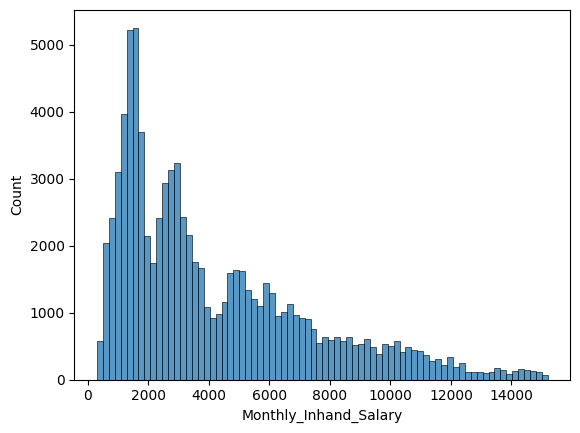

In [28]:
_ = sns.histplot(df_baseline, x="Monthly_Inhand_Salary")

In [29]:
df_baseline["Monthly_Inhand_Salary"].isnull().sum()

np.int64(15002)

In [30]:
df_baseline.groupby("Customer_ID")["Monthly_Inhand_Salary"].apply(
    lambda x: x.isnull().sum()
).value_counts()

Monthly_Inhand_Salary
1    4862
0    3401
2    2904
3    1048
4     240
5      42
6       3
Name: count, dtype: int64

In [31]:
df_baseline.groupby("Customer_ID")["Monthly_Inhand_Salary"].transform("mean")

0       1,824.84
1       1,824.84
2       1,824.84
3       1,824.84
4       1,824.84
          ...   
99995   3,359.42
99996   3,359.42
99997   3,359.42
99998   3,359.42
99999   3,359.42
Name: Monthly_Inhand_Salary, Length: 100000, dtype: float64

In [32]:
df_baseline["Monthly_Inhand_Salary"] = df_baseline["Monthly_Inhand_Salary"].fillna(
    df_baseline.groupby("Customer_ID")["Monthly_Inhand_Salary"].transform("mean")
)

print(df_baseline["Monthly_Inhand_Salary"].describe())
print(df_baseline["Monthly_Inhand_Salary"].isnull().sum())

count   100,000.00
mean      4,198.47
std       3,187.37
min         303.65
25%       1,626.59
50%       3,096.38
75%       5,961.64
max      15,204.63
Name: Monthly_Inhand_Salary, dtype: float64
0


### type of loan

In [33]:
df_baseline["Type_of_Loan"].unique()

<StringArray>
[                                                     'Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
                                                                                                      'Credit-Builder Loan',
                                                                                  'Auto Loan, Auto Loan, and Not Specified',
                                                                                                            'Not Specified',
                                                                                                                        nan,
                                                                                   'Credit-Builder Loan, and Mortgage Loan',
                                                                               'Not Specified, Auto Loan, and Student Loan',
                                                                    'Personal Loan, Debt Consolidation Loan, an

In [34]:
df_baseline.groupby("Customer_ID")["Type_of_Loan"].apply(
    lambda x: x.isnull().sum()
).value_counts()

Type_of_Loan
0    11074
8     1426
Name: count, dtype: int64

In [35]:
df_baseline.groupby("Customer_ID")["Type_of_Loan"].apply(
    lambda x: x.isnull().sum()
).sort_values()

Customer_ID
CUS_0x1000    0
CUS_0x8924    0
CUS_0x8927    0
CUS_0x8928    0
CUS_0x892d    0
             ..
CUS_0x8a0e    8
CUS_0x23d8    8
CUS_0x9fdc    8
CUS_0x23b0    8
CUS_0x5d1c    8
Name: Type_of_Loan, Length: 12500, dtype: int64

In [36]:
df[df["Customer_ID"] == "CUS_0x8a0e"]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
5496,0x3636,CUS_0x8a0e,January,Gellera,50,601-77-9732,Mechanic,131617.4,NaN,4,3,15,0,NaN,13,20,1.82,2.00,Standard,929.47,28.62,21 Years and 7 Months,No,0.00,739.9024762603663,Low_spent_Medium_value_payments,614.3091904063007,Standard
5497,0x3637,CUS_0x8a0e,February,Gellera,50,601-77-9732,_______,131617.4,"10,742.12",4,3,15,0,NaN,13,NaN,1.82,2.00,Standard,929.47,35.07,21 Years and 8 Months,No,0.00,926.649726570325,Low_spent_Medium_value_payments,427.5619400963418,Standard
5498,0x3638,CUS_0x8a0e,March,Gellera,51,601-77-9732,Mechanic,131617.4,NaN,4,3,15,0,NaN,13,18,1.82,7.00,Standard,929.47,39.59,21 Years and 9 Months,No,0.00,315.9685537658126,High_spent_Medium_value_payments,1008.2431129008542,Standard
5499,0x3639,CUS_0x8a0e,April,Gellera,51,601-77-9732,Mechanic,131617.4,"10,742.12",4,3,15,0,NaN,8,20,1.82,7.00,Standard,929.47,30.94,21 Years and 10 Months,No,0.00,439.8156246683498,Low_spent_Medium_value_payments,914.3960419983168,Standard
5500,0x363a,CUS_0x8a0e,May,Gellera,51,601-77-9732,Mechanic,131617.4,NaN,4,3,15,0,NaN,13,20,1.82,7.00,Standard,929.47,25.46,21 Years and 11 Months,No,0.00,1384.9710956698707,Low_spent_Small_value_payments,NaN,Standard
5501,0x363b,CUS_0x8a0e,June,Gellera,51,601-77-9732,Mechanic,131617.4,NaN,4,3,15,0,NaN,16,20,1.82,7.00,Standard,929.47,35.04,22 Years and 0 Months,No,0.00,842.2799453230798,Low_spent_Medium_value_payments,511.9317213435869,Standard
5502,0x363c,CUS_0x8a0e,July,Gellera,51,601-77-9732,Mechanic,131617.4,"10,742.12",4,3,15,0,NaN,13,20,5.82,7.00,Standard,929.47,29.59,22 Years and 1 Months,No,0.00,821.4385437166835,Low_spent_Small_value_payments,542.7731229499833,Standard
5503,0x363d,CUS_0x8a0e,August,Gellera,51,601-77-9732,Mechanic,131617.4,"10,742.12",4,3,15,0,NaN,13,20,1.82,7.00,Standard,929.47,36.85,22 Years and 2 Months,No,0.00,163.61342783213706,High_spent_Medium_value_payments,1160.5982388345296,Poor


In [37]:
type_of_loan_cleaned = df_baseline["Type_of_Loan"].str.replace("and", "")
type_of_loan_cleaned = type_of_loan_cleaned.str.strip()
type_of_loan_cleaned = type_of_loan_cleaned.str.split(",")
loans = type_of_loan_cleaned.explode().str.strip().unique()
loans = loans.dropna()
loans

<StringArray>
[              'Auto Loan',     'Credit-Builder Loan',
           'Personal Loan',        'Home Equity Loan',
           'Not Specified',           'Mortgage Loan',
            'Student Loan', 'Debt Consolidation Loan',
             'Payday Loan']
Length: 9, dtype: str

In [38]:
new_cols = []
for loan in loans:
    name = "has_" + loan

    df_baseline[name] = df_baseline["Type_of_Loan"].str.contains(loan, na=False)
    df_baseline[name] = df_baseline[name].astype("int")
    new_cols.append(name)

df_baseline["has_Not Specified"] = np.where(
    df_baseline["Type_of_Loan"].isnull(), True, df_baseline["has_Not Specified"]
)

df_baseline[new_cols].sum()

has_Auto Loan                  30560
has_Credit-Builder Loan        31728
has_Personal Loan              31104
has_Home Equity Loan           31400
has_Not Specified              43088
has_Mortgage Loan              31360
has_Student Loan               31040
has_Debt Consolidation Loan    31040
has_Payday Loan                31944
dtype: int64

### delay_from_due_date

In [39]:
df_baseline[df_baseline["Delay_from_due_date"] < 0].head()

,Customer_ID,Month,Age,Monthly_Inhand_Salary,Type_of_Loan,Delay_from_due_date,Credit_History_Age,Payment_of_Min_Amount,Credit_Score,num_month,Age_cleaned,has_Auto Loan,has_Credit-Builder Loan,has_Personal Loan,has_Home Equity Loan,has_Not Specified,has_Mortgage Loan,has_Student Loan,has_Debt Consolidation Loan,has_Payday Loan
1,CUS_0xd40,February,23,"1,824.84","Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,No,Good,202202,23.00,1,1,1,1,0,0,0,0,0
49,CUS_0x284a,February,34,"11,242.78","Credit-Builder Loan, and Mortgage Loan",-1,30 Years and 8 Months,No,Good,202202,34.00,0,1,0,0,0,1,0,0,0
74,CUS_0xba08,March,44,"2,825.23","Not Specified, and Payday Loan",-2,26 Years and 7 Months,No,Good,202203,44.00,0,0,0,0,1,0,0,0,1
78,CUS_0xba08,July,45,"2,825.23","Not Specified, and Payday Loan",-1,26 Years and 11 Months,No,Good,202207,45.00,0,0,0,0,1,0,0,0,1
79,CUS_0xba08,August,45,"2,825.23","Not Specified, and Payday Loan",-2,27 Years and 0 Months,No,Good,202208,45.00,0,0,0,0,1,0,0,0,1


In [40]:
df_baseline["Delay_from_due_date"].isnull().sum()

np.int64(0)

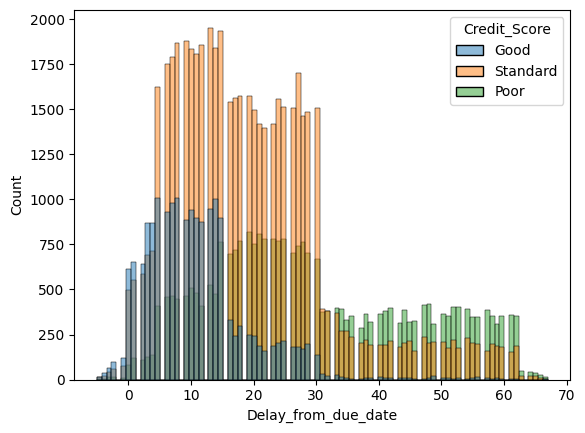

In [41]:
_ = sns.histplot(df_baseline, x="Delay_from_due_date", hue="Credit_Score")

### Credit_History_Age

In [42]:
df_baseline.groupby("Customer_ID")["Credit_History_Age"].apply(
    lambda x: x.isnull().sum()
).value_counts()

Credit_History_Age
0    5850
1    4666
2    1626
3     322
4      34
5       2
Name: count, dtype: int64

In [43]:
df_baseline.groupby("Customer_ID")["Credit_History_Age"].apply(
    lambda x: x.isnull().sum()
).sort_values()

Customer_ID
CUS_0x1000    0
CUS_0x75ca    0
CUS_0x75c6    0
CUS_0x75c4    0
CUS_0x75ba    0
             ..
CUS_0x235a    4
CUS_0x6057    4
CUS_0xa328    4
CUS_0x489     5
CUS_0x38c0    5
Name: Credit_History_Age, Length: 12500, dtype: int64

In [44]:
df[df["Customer_ID"] == "CUS_0x38c0"]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
33592,0xdad6,CUS_0x38c0,January,Abhishekx,33,083-35-9736,Musician,15660.15_,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",45,14_,2.46,9.00,Bad,1354.33,36.83,NaN,Yes,57.29,143.99214855182413,Low_spent_Small_value_payments,225.0184220161142,Standard
33593,0xdad7,CUS_0x38c0,February,Abhishekx,33,083-35-9736,Musician,15660.15,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",45,17,2.46,9.00,Bad,1354.33,31.86,NaN,Yes,57.29,97.22995233141016,Low_spent_Small_value_payments,271.78061823652814,Poor
33594,0xdad8,CUS_0x38c0,March,Abhishekx,33,083-35-9736,Musician,15660.15,NaN,9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",45,18,2.46,9.00,Bad,1354.33,34.45,8 Years and 1 Months,Yes,57.29,153.88722462479603,!@9#%8,215.12334594314228,Poor
33595,0xdad9,CUS_0x38c0,April,Abhishekx,33,083-35-9736,Musician,15660.15,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",46,16,2.46,9.00,Bad,1354.33,34.31,8 Years and 2 Months,Yes,57.29,99.69806912864614,!@9#%8,269.3125014392922,Poor
33596,0xdada,CUS_0x38c0,May,Abhishekx,33,083-35-9736,Musician,15660.15,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",45,15,5.46,9.00,_,1354.33,27.51,8 Years and 3 Months,Yes,57.29,54.478248631883105,Low_spent_Small_value_payments,314.5323219360552,Poor
33597,0xdadb,CUS_0x38c0,June,Abhishekx,33,083-35-9736,Musician,15660.15,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",40,17,2.46,9.00,Bad,1354.33,36.86,NaN,Yes,57.29,85.14120194283548,Low_spent_Small_value_payments,283.8693686251028,Poor
33598,0xdadc,CUS_0x38c0,July,Abhishekx,33,083-35-9736,_______,15660.15,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",45,12,7.46,9.00,_,1354.33,38.63,NaN,NM,57.29,59.084492288745906,Low_spent_Medium_value_payments,299.92607827919244,Standard
33599,0xdadd,CUS_0x38c0,August,Abhishekx,33,083-35-9736,Musician,15660.15_,"1,363.01",9,10,23,5,"Not Specified, Not Specified, Personal Loan, P...",45,15,2.46,NaN,Bad,1354.33,38.19,NaN,Yes,57.29,125.0706368947691,Low_spent_Large_value_payments,223.93993367316918,Poor


In [45]:
credit_h_age = df_baseline["Credit_History_Age"].str.split()
print(credit_h_age.value_counts(dropna=False))
# print(credit_h_age.str.len().value_counts())

Credit_History_Age
NaN                             9030
[15, Years, and, 11, Months]     446
[19, Years, and, 4, Months]      445
[19, Years, and, 5, Months]      444
[17, Years, and, 11, Months]     443
                                ... 
[0, Years, and, 3, Months]        20
[0, Years, and, 2, Months]        15
[33, Years, and, 7, Months]       14
[33, Years, and, 8, Months]       12
[0, Years, and, 1, Months]         2
Name: count, Length: 405, dtype: int64


In [46]:
credit_h_age = df_baseline["Credit_History_Age"].str.split()

df_baseline["Credit_History_Age_numeric"] = credit_h_age.str[0].astype(
    "Int64"
) * 12 + credit_h_age.str[3].astype("Int64")
df_baseline["Credit_History_Age_numeric"].describe()

count   90,970.00
mean       221.20
std         99.74
min          1.00
25%        144.00
50%        219.00
75%        302.00
max        404.00
Name: Credit_History_Age_numeric, dtype: Float64

In [47]:
df_baseline = df_baseline.sort_values(["Customer_ID", "num_month"])
df_baseline["Credit_History_Age_numeric"] = df_baseline[
    "Credit_History_Age_numeric"
].astype(float)
df_baseline["Credit_History_Age_numeric"] = (
    df_baseline.groupby("Customer_ID")["Credit_History_Age_numeric"]
    .apply(fill_credit_age)
    .reset_index(level=0, drop=True)
)

df_baseline.describe()

,Age,Monthly_Inhand_Salary,Delay_from_due_date,num_month,Age_cleaned,has_Auto Loan,has_Credit-Builder Loan,has_Personal Loan,has_Home Equity Loan,has_Not Specified,has_Mortgage Loan,has_Student Loan,has_Debt Consolidation Loan,has_Payday Loan,Credit_History_Age_numeric
count,"100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00"
mean,110.65,"4,198.47",21.07,"202,204.50",34.39,0.31,0.32,0.31,0.31,0.43,0.31,0.31,0.31,0.32,221.14
std,686.24,"3,187.37",14.86,2.29,9.68,0.46,0.47,0.46,0.46,0.50,0.46,0.46,0.46,0.47,99.68
min,-500.00,303.65,-5.00,"202,201.00",18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,24.00,"1,626.59",10.00,"202,202.75",27.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,144.00
50%,33.00,"3,096.38",18.00,"202,204.50",34.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,219.00
75%,42.00,"5,961.64",28.00,"202,206.25",41.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,302.00
max,"8,698.00","15,204.63",67.00,"202,208.00",56.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,404.00


### Payment_of_Min_Amount

In [48]:
df_baseline["Payment_of_Min_Amount"].value_counts()

Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

<Axes: xlabel='Payment_of_Min_Amount'>

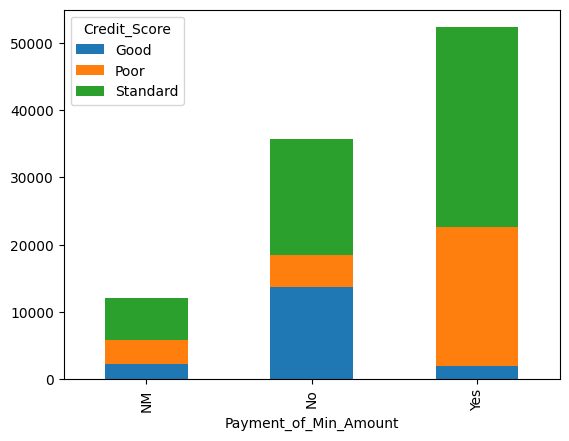

In [49]:
pd.crosstab(
    df_baseline["Credit_Score"],
    df_baseline["Payment_of_Min_Amount"],
    # normalize="columns"
).T.plot(
    stacked=True,
    kind="bar",
)

In [50]:
all([True, False])

False

In [51]:
print(
    df_baseline.groupby("Customer_ID")["Payment_of_Min_Amount"].nunique().value_counts()
)
check = df_baseline.groupby("Customer_ID")["Payment_of_Min_Amount"].unique()
check.apply(lambda x: tuple(sorted(x))).value_counts()

Payment_of_Min_Amount
2    8009
1    4491
Name: count, dtype: int64


Payment_of_Min_Amount
(NM, Yes)    4748
(NM, No)     3261
(Yes,)       2681
(No,)        1810
Name: count, dtype: int64

In [52]:
df[df["Customer_ID"] == "CUS_0x6da8"]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
43848,0x116ee,CUS_0x6da8,January,Caroline Valetkevitchu,20,566-95-6703,Accountant,37607.28,"2,842.94",3,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,14,15.0,9.00,Standard,1361.67,38.65,18 Years and 10 Months,Yes,81.82,101.96031965845924,High_spent_Small_value_payments,360.51677427328906,Poor
43849,0x116ef,CUS_0x6da8,February,Caroline Valetkevitchu,21,566-95-6703,Accountant,37607.28,"2,842.94",1461,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,15,18.0,9.00,Standard,1361.67,29.15,18 Years and 11 Months,NM,81.82,170.97373474354038,High_spent_Small_value_payments,291.5033591882078,Standard
43850,0x116f0,CUS_0x6da8,March,Caroline Valetkevitchu,21,566-95-6703,Accountant,37607.28,"2,842.94",3,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,14,15.0,9.00,Standard,1361.67,39.43,19 Years and 0 Months,Yes,81.82,263.05102494056285,Low_spent_Small_value_payments,229.4260689911854,Poor
43851,0x116f1,CUS_0x6da8,April,NaN,21,566-95-6703,Accountant,37607.28,"2,842.94",3,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,12,15.0,9.00,Standard,1361.67,36.69,19 Years and 1 Months,Yes,81.82,NaN,High_spent_Large_value_payments,403.195117137898,Poor
43852,0x116f2,CUS_0x6da8,May,Caroline Valetkevitchu,21,566-95-6703,Accountant,37607.28,"2,842.94",3,6,17,3_,"Home Equity Loan, Auto Loan, and Not Specified",15,12,17.0,9.00,Standard,1361.67,36.97,19 Years and 2 Months,Yes,81.82,375.30735040476105,Low_spent_Small_value_payments,117.16974352698715,Poor
43853,0x116f3,CUS_0x6da8,June,Caroline Valetkevitchu,21,566-95-6703,Accountant,37607.28,"2,842.94",3,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,15,15.0,9.00,_,1361.67,24.65,19 Years and 3 Months,Yes,81.82,127.8519385904503,Low_spent_Large_value_payments,344.6251553412979,Poor
43854,0x116f4,CUS_0x6da8,July,Caroline Valetkevitchu,21,#F%$D@*&8,Accountant,37607.28,"2,842.94",3,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,14,15.0,522.00,Standard,1361.67,37.48,19 Years and 4 Months,Yes,81.82,42.05528629476576,High_spent_Medium_value_payments,410.4218076369825,Poor
43855,0x116f5,CUS_0x6da8,August,Caroline Valetkevitchu,21,566-95-6703,Accountant,37607.28,"2,842.94",3,6,17,3,"Home Equity Loan, Auto Loan, and Not Specified",16,14,21.0,9.00,Standard,1361.67,33.16,NaN,NM,81.82,170.93834074861672,High_spent_Small_value_payments,291.53875318313146,Poor


In [53]:
cat_cols = ["Payment_of_Min_Amount"]

new_dummies = pd.get_dummies(df[cat_cols], cat_cols, drop_first=True, dtype="int")

df_baseline = pd.concat(
    [df_baseline, new_dummies],
    axis=1,
)


### target

In [54]:
df_baseline["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [55]:
df_baseline["target"] = df_baseline["Credit_Score"].map(
    {"Standard": 0, "Good": 0, "Poor": 1}
)
df_baseline["target"].value_counts()

target
0    71002
1    28998
Name: count, dtype: int64

In [56]:
df_baseline.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 56752 to 99159
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Customer_ID                  100000 non-null  str    
 1   Month                        100000 non-null  str    
 2   Age                          100000 non-null  int64  
 3   Monthly_Inhand_Salary        100000 non-null  float64
 4   Type_of_Loan                 88592 non-null   str    
 5   Delay_from_due_date          100000 non-null  int64  
 6   Credit_History_Age           90970 non-null   str    
 7   Payment_of_Min_Amount        100000 non-null  str    
 8   Credit_Score                 100000 non-null  str    
 9   num_month                    100000 non-null  int64  
 10  Age_cleaned                  100000 non-null  float64
 11  has_Auto Loan                100000 non-null  int64  
 12  has_Credit-Builder Loan      100000 non-null  int64  
 13  has_Personal

# Modelling

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    average_precision_score,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

### Preprocessing

In [58]:
FEATURE_COLS = [
    "Age_cleaned",
    "Credit_History_Age_numeric",
    "Delay_from_due_date",
    "Monthly_Inhand_Salary",
    "Payment_of_Min_Amount_No",
    "Payment_of_Min_Amount_Yes",
] + new_cols
X = df_baseline[FEATURE_COLS]
y = df_baseline["target"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y, test_size=0.25
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75000, 15)
(25000, 15)
(75000,)
(25000,)


### modelling

In [60]:
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
scale_pos_weight

np.float64(2.4485136905993516)

In [61]:
xgb = XGBClassifier(
    # scale_pos_weight = scale_pos_weight,
    n_estimators=200
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [62]:
rdf = RandomForestClassifier(n_estimators=200)

rdf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
scaler = StandardScaler()
lgr_numfeat = ["Age_cleaned", "Credit_History_Age_numeric", "Monthly_Inhand_Salary"]

In [64]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[lgr_numfeat] = scaler.fit_transform(X_train_scaled[lgr_numfeat])
X_test_scaled[lgr_numfeat] = scaler.transform(X_test_scaled[lgr_numfeat])
X_test_scaled

,Age_cleaned,Credit_History_Age_numeric,Delay_from_due_date,Monthly_Inhand_Salary,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,has_Auto Loan,has_Credit-Builder Loan,has_Personal Loan,has_Home Equity Loan,has_Not Specified,has_Mortgage Loan,has_Student Loan,has_Debt Consolidation Loan,has_Payday Loan
84486,-0.35,-0.18,7,1.50,1,0,0,0,1,0,0,0,0,0,0
35210,-0.77,-0.25,24,-0.95,0,1,0,1,0,0,0,1,1,1,1
6736,-0.04,-0.04,59,-0.95,0,1,0,0,0,0,0,1,0,0,1
87134,1.61,1.46,10,0.15,0,1,0,0,0,1,0,0,0,0,1
9503,1.41,1.82,13,0.55,0,1,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3200,0.89,-0.15,29,-1.01,0,1,0,1,0,0,0,0,0,0,1
99271,-1.08,1.25,14,0.61,1,0,0,0,0,1,0,0,0,1,0
31648,0.89,0.35,6,-0.35,0,1,0,0,0,0,1,0,0,0,0
81672,0.78,1.43,3,-0.31,1,0,0,1,0,0,0,0,0,0,0


In [65]:
lgr = LogisticRegression(class_weight="balanced")

lgr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### Evaluation

In [66]:
thresholds = np.arange(0.0, 1, 0.1)
thresholds

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [67]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    report = {
        "Model": model_name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "roc_auc_score": roc_auc_score(y_true, y_proba),
        "pr_auc_score": average_precision_score(y_true, y_proba),
        "f1": f1_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
    }

    return report


def evaluate_thresholds(y_true, y_proba):

    thresholds = np.arange(0, 1, 0.1)

    report = []

    for thresh in thresholds:

        y_pred = (y_proba >= thresh).astype("int")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        results = {
            "threshold": thresh,
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "f1_score": f1_score(y_true, y_pred),
            "Total_positives": y_test.sum(),
            "Total_preds": y_pred.sum(),
            "True_Postiives": tp,
            "False_Positives": fp,
        }

        report.append(results)

    return pd.DataFrame(report)

In [69]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

y_pred_rdf = rdf.predict(X_test)
y_proba_rdf = rdf.predict_proba(X_test)[:, 1]

y_pred_lgr = lgr.predict(X_test_scaled)
y_proba_lgr = lgr.predict_proba(X_test_scaled)[:, 1]

In [70]:
pd.DataFrame(
    [
        evaluate_model(y_test, y_pred_xgb, y_proba_xgb, "xgb"),
        evaluate_model(y_test, y_pred_rdf, y_proba_rdf, "rdf"),
        evaluate_model(y_test, y_pred_lgr, y_proba_lgr, "lgr"),
    ]
)

,Model,Precision,Recall,roc_auc_score,pr_auc_score,f1,accuracy
0,xgb,0.76,0.67,0.90,0.76,0.71,0.84
1,rdf,0.81,0.77,0.94,0.81,0.79,0.88
2,lgr,0.53,0.70,0.76,0.53,0.60,0.73


<Axes: >

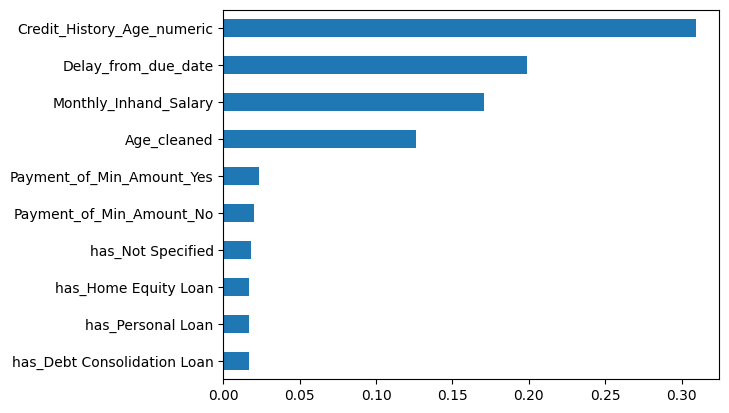

In [78]:
feature_importances = pd.Series(
    rdf.feature_importances_,
    X.columns,
)
feature_importances.sort_values().tail(10).plot(kind="barh")

# Eval thresholds

In [71]:
evaluate_thresholds(y_test, y_proba_rdf)

,threshold,precision,recall,f1_score,Total_positives,Total_preds,True_Postiives,False_Positives
0,0.00,0.29,1.00,0.45,7249,25000,7249,17751
1,0.10,0.60,0.98,0.74,7249,11789,7075,4714
2,0.20,0.70,0.94,0.80,7249,9711,6815,2896
3,0.30,0.76,0.89,0.82,7249,8458,6450,2008
4,0.40,0.79,0.83,0.81,7249,7605,5999,1606
5,0.50,0.80,0.78,0.79,7249,6998,5627,1371
6,0.60,0.82,0.71,0.76,7249,6301,5144,1157
7,0.70,0.83,0.62,0.71,7249,5404,4468,936
8,0.80,0.84,0.50,0.62,7249,4320,3609,711
9,0.90,0.84,0.32,0.47,7249,2776,2342,434


# xd

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
df = fetch_california_housing(as_frame=True)
df = df.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
y = df["MedHouseVal"]
X = df.drop(columns="MedHouseVal")

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
features = X.columns

X[features] = scaler.fit_transform(X)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818
...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15480, 8)
(5160, 8)
(15480,)
(5160,)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression(fit_intercept=True)

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

y_pred = lr.predict(X_test)

print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.5296964012919461
0.5910509795491352
0.5411287478470688


In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgbr = XGBRegressor()

xgbr.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [ ]:
y_pred_xgbr = xgbr.predict(X_test)

print(mean_absolute_error(y_test, y_pred_xgbr))
print(mean_squared_error(y_test, y_pred_xgbr))
print(r2_score(y_test, y_pred_xgbr))
print(lr.coef_)
print(lr.intercept_)

0.30543454174638346
0.2161409990991321
0.8366550470428123
[ 0.85033973  0.12040973 -0.30866036  0.37649943 -0.0016296  -0.03575913
 -0.89399245 -0.8683199 ]
2.0682681194892076


In [79]:
from sklearn.cluster import KMeans

In [81]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(X_train_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [86]:
y_cluster = kmeans.predict(X_test_scaled)
labels = kmeans.labels_
print(y_cluster)
print(labels)
kmeans.cluster_centers_

[0 4 3 ... 0 0 1]
[2 0 4 ... 2 3 4]


array([[ 1.47024205e-01,  4.96563953e-01,  6.41937042e+00,
         2.83712555e-01,  6.23699346e-01,  2.54906265e-01,
         2.18246477e-01,  2.32251833e-01,  2.25095491e-01,
         2.31022523e-01,  4.01589323e-01,  2.25929666e-01,
         2.28607806e-01,  2.31066427e-01,  2.33305528e-01],
       [-2.64749163e-01, -9.78387636e-01,  4.15549056e+01,
        -4.33973416e-01,  2.33996323e-03,  8.78154772e-01,
         4.77686779e-01,  5.12117667e-01,  5.00919271e-01,
         4.83035267e-01,  4.72338292e-01,  5.14791910e-01,
         4.88216614e-01,  4.98412168e-01,  4.74511115e-01],
       [ 2.32736357e-02,  1.51223980e-01,  1.61620651e+01,
         5.56521571e-02,  3.94599384e-01,  4.84003358e-01,
         2.75673911e-01,  2.87100084e-01,  2.76793210e-01,
         2.83602276e-01,  4.28644716e-01,  2.81876691e-01,
         2.78845257e-01,  2.70357243e-01,  2.80897304e-01],
       [-2.52266165e-01, -9.61837063e-01,  5.56845925e+01,
        -4.52128054e-01,  2.05391260e-15,  8.81887166